# 08. 공간 자기상관 분석 — Moran's I
## 고령 1인가구 복합위기 지수(CCI)의 공간 클러스터 구조 분석

**목적**: CCI가 공간적으로 무작위 분포하는지, 아니면 특정 지역에 집중(클러스터)되는지 검증합니다.

| 분석 | 내용 |
|------|------|
| Global Moran's I | 전체 서울 행정동 차원의 공간 자기상관 강도 |
| Local Moran's I (LISA) | 동별 핫스팟(HH)·콜드스팟(LL) 식별 |
| Moran Scatter Plot | I 통계량 시각화 |

---
## 1. 설정 및 데이터 로드

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import libpysal
from esda.moran import Moran, Moran_Local
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

BASE_DIR   = Path('c:/Tsum2026/T_SUM2026')
OUTPUT_DIR = BASE_DIR / 'data' / 'output'
FIG_DIR    = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(OUTPUT_DIR / 'final_crisis_index_by_dong_2021.gpkg')
# None/빈 지오메트리 제거
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
print(f'데이터 로드: {gdf.shape}')
print(f'CRS: {gdf.crs}')
print(f'컬럼: {gdf.columns.tolist()}')

데이터 로드: (420, 16)
CRS: EPSG:5179
컬럼: ['행정동코드', '기준연도', '자치구명', '행정동명', 'IVI', 'CDI', 'RII', 'CCI', 'CCI_rank', 'CCI_grade', 'IVI_top30_flag', 'CDI_top30_flag', 'RII_top30_flag', 'triple_high_flag', 'risk_type', 'geometry']


---
## 2. 공간 가중치 행렬 생성 (Queen Contiguity)

In [2]:
# Queen contiguity — 변을 공유하거나 꼭짓점만 닿아도 인접으로 처리
w = libpysal.weights.Queen.from_dataframe(gdf, silence_warnings=True)
w.transform = 'r'  # row-standardize

print(f'행정동 수: {w.n}')
print(f'평균 인접 이웃 수: {w.mean_neighbors:.2f}')
print(f'최소/최대 이웃: {w.min_neighbors}/{w.max_neighbors}')
print(f'연결 없는 고립 동: {len(w.islands)}개')

행정동 수: 420
평균 인접 이웃 수: 5.71
최소/최대 이웃: 1/14
연결 없는 고립 동: 0개


---
## 3. Global Moran's I — IVI / CDI / RII / CCI

In [3]:
INDICATORS = ['CCI', 'IVI', 'CDI', 'RII']
global_results = []

for col in INDICATORS:
    mi = Moran(gdf[col], w)
    global_results.append({
        '지표':     col,
        "Moran's I": round(mi.I, 4),
        'E[I]':     round(mi.EI, 4),
        'z-score':  round(mi.z_norm, 3),
        'p-value':  round(mi.p_norm, 4),
        'p-sim':    round(mi.p_sim, 4),
        '해석':     '유의미한 공간 군집' if mi.p_sim < 0.05 else '공간 무작위'
    })

global_df = pd.DataFrame(global_results)
print('=== Global Moran\'s I 결과 ===')
display(global_df)

=== Global Moran's I 결과 ===


,지표,Moran's I,E[I],z-score,p-value,p-sim,해석
0,CCI,0.4100,-0.0024,14.036,0.0,0.001,유의미한 공간 군집
1,IVI,0.5586,-0.0024,19.093,0.0,0.001,유의미한 공간 군집
2,CDI,0.3071,-0.0024,10.535,0.0,0.001,유의미한 공간 군집
3,RII,0.2816,-0.0024,9.665,0.0,0.001,유의미한 공간 군집


---
## 4. Moran Scatter Plot — CCI

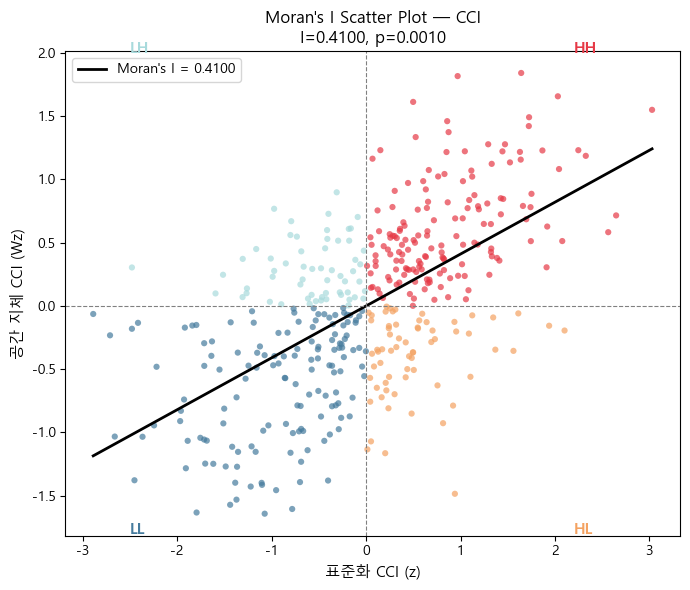

저장: c:\Tsum2026\T_SUM2026\outputs\figures\moran_scatter_cci.png


In [4]:
from esda.moran import Moran

cci_vals = gdf['CCI'].values
mi_cci   = Moran(cci_vals, w)
z_cci    = (cci_vals - cci_vals.mean()) / cci_vals.std()
wz_cci   = libpysal.weights.lag_spatial(w, z_cci)

fig, ax = plt.subplots(figsize=(7, 6))

# 사분면 색상
colors = []
for z, wz in zip(z_cci, wz_cci):
    if z >= 0 and wz >= 0:   colors.append('#E63946')  # HH (빨강)
    elif z < 0 and wz < 0:   colors.append('#457B9D')  # LL (파랑)
    elif z >= 0 and wz < 0:  colors.append('#F4A261')  # HL (주황)
    else:                     colors.append('#A8DADC')  # LH (하늘)

ax.scatter(z_cci, wz_cci, c=colors, s=20, alpha=0.7, edgecolors='none')

# 회귀선 (기울기 = Moran's I)
xfit = np.linspace(z_cci.min(), z_cci.max(), 100)
ax.plot(xfit, mi_cci.I * xfit, 'k-', linewidth=2, label=f"Moran's I = {mi_cci.I:.4f}")

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# 사분면 라벨
for text, xy in [('HH', (2.2, 2.0)), ('HL', (2.2, -1.8)),
                 ('LL', (-2.5, -1.8)), ('LH', (-2.5, 2.0))]:
    ax.text(*xy, text, fontsize=11, fontweight='bold',
            color={'HH':'#E63946','HL':'#F4A261','LL':'#457B9D','LH':'#A8DADC'}[text])

ax.set_xlabel('표준화 CCI (z)', fontsize=11)
ax.set_ylabel('공간 지체 CCI (Wz)', fontsize=11)
ax.set_title(f"Moran's I Scatter Plot — CCI\nI={mi_cci.I:.4f}, p={mi_cci.p_sim:.4f}",
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
path_scatter = FIG_DIR / 'moran_scatter_cci.png'
plt.savefig(path_scatter, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_scatter}')

---
## 5. Local Moran's I (LISA) — 공간 클러스터 동 식별

In [5]:
lisa = Moran_Local(gdf['CCI'], w, transformation='r', permutations=999)

gdf['lisa_I']   = lisa.Is
gdf['lisa_q']   = lisa.q
gdf['lisa_p']   = lisa.p_sim
gdf['lisa_sig'] = lisa.p_sim < 0.05

quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
gdf['lisa_cluster'] = gdf.apply(
    lambda r: quad_map.get(r['lisa_q'], 'NS') if r['lisa_sig'] else 'NS', axis=1
)

cluster_counts = gdf['lisa_cluster'].value_counts()
print('=== LISA 클러스터 분포 ===')
print(cluster_counts.to_string())
print()

for ct in ['HH', 'LH', 'LL', 'HL']:
    sub = gdf[gdf['lisa_cluster'] == ct][['자치구명', '행정동명', 'CCI', 'triple_high_flag']]
    print(f'--- {ct} ({len(sub)}개) ---')
    if len(sub) > 0:
        print(sub.sort_values('CCI', ascending=False).to_string(index=False))
    print()

=== LISA 클러스터 분포 ===
lisa_cluster
NS    292
HH     57
LL     55
HL     11
LH      5

--- HH (57개) ---
자치구명  행정동명      CCI  triple_high_flag
 강북구   번2동 0.671819                 0
 은평구  응암3동 0.646154                 0
 강북구  수유2동 0.624484                 1
 강북구   번3동 0.619163                 0
 중랑구  신내2동 0.605369                 1
 강북구   번1동 0.604541                 0
 은평구  신사2동 0.593513                 1
 도봉구  쌍문2동 0.585707                 0
 관악구  보라매동 0.585018                 1
 강북구  수유3동 0.583983                 0
 강북구   인수동 0.583794                 0
 은평구   녹번동 0.579606                 1
 강북구   미아동 0.578347                 0
 강북구   삼양동 0.578014                 0
 은평구  갈현2동 0.577451                 0
 도봉구  도봉1동 0.570334                 0
 은평구   구산동 0.566782                 1
 도봉구   창5동 0.565495                 0
 은평구   증산동 0.564964                 0
 중랑구  신내1동 0.563832                 0
동대문구 답십리1동 0.563781                 0
 은평구   역촌동 0.557291                 1
 강북구   우이동 0.554788     

---
## 6. LISA 클러스터 지도

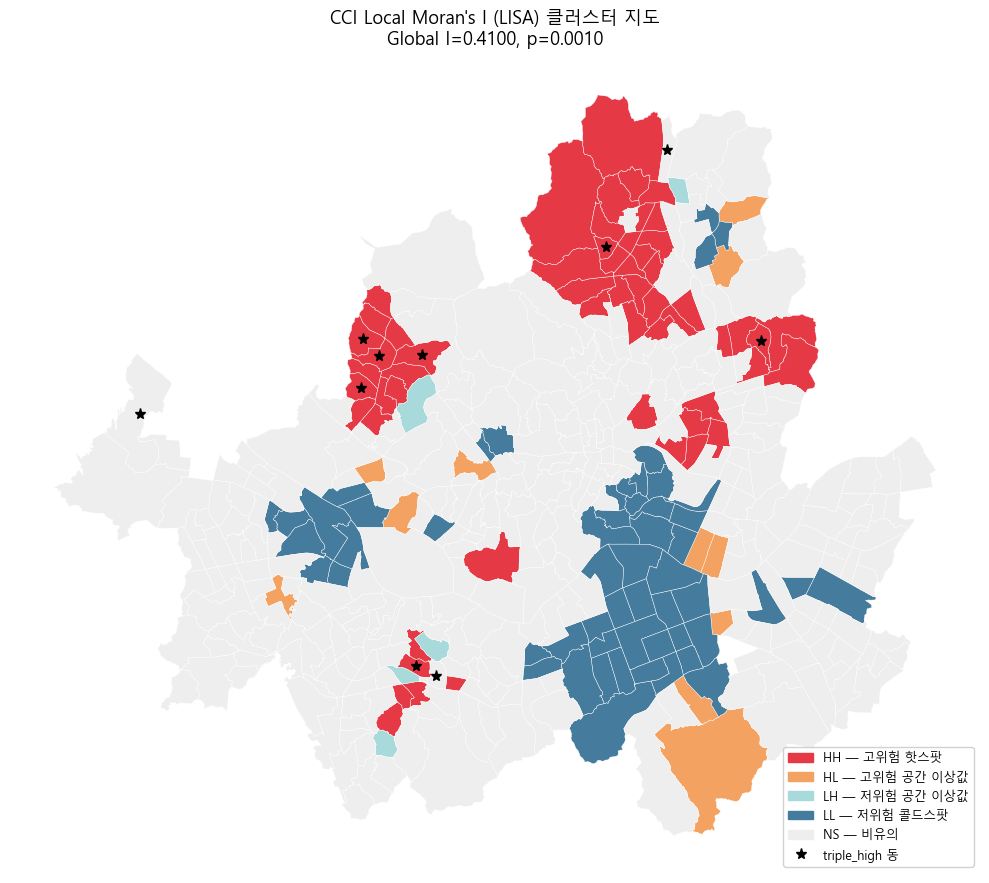

저장: c:\Tsum2026\T_SUM2026\outputs\figures\moran_lisa_cluster_map.png


In [6]:
CLUSTER_COLORS = {
    'HH': '#E63946',   # 핫스팟 (고위험 밀집)
    'HL': '#F4A261',   # 공간 이상값 (고위험+저위험 인접)
    'LH': '#A8DADC',   # 공간 이상값 (저위험+고위험 인접)
    'LL': '#457B9D',   # 콜드스팟 (저위험 밀집)
    'NS': '#EEEEEE',   # 비유의
}

gdf_plot = gdf.copy()
if gdf_plot.crs.to_epsg() != 5179:
    gdf_plot = gdf_plot.to_crs(epsg=5179)

fig, ax = plt.subplots(figsize=(10, 12))
for cluster_type, color in CLUSTER_COLORS.items():
    subset = gdf_plot[gdf_plot['lisa_cluster'] == cluster_type]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3)

# triple_high 동 강조 (별표 중심점)
triple_gdf = gdf_plot[gdf_plot['triple_high_flag'] == 1].copy()
triple_gdf['centroid'] = triple_gdf.geometry.centroid
for _, row in triple_gdf.iterrows():
    ax.plot(row['centroid'].x, row['centroid'].y, 'k*', markersize=8, zorder=5)

legend_patches = [
    mpatches.Patch(color='#E63946', label='HH — 고위험 핫스팟'),
    mpatches.Patch(color='#F4A261', label='HL — 고위험 공간 이상값'),
    mpatches.Patch(color='#A8DADC', label='LH — 저위험 공간 이상값'),
    mpatches.Patch(color='#457B9D', label='LL — 저위험 콜드스팟'),
    mpatches.Patch(color='#EEEEEE', label='NS — 비유의'),
    plt.Line2D([0],[0], marker='*', color='black', markersize=8, linewidth=0, label='triple_high 동'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title(f"CCI Local Moran's I (LISA) 클러스터 지도\nGlobal I={mi_cci.I:.4f}, p={mi_cci.p_sim:.4f}",
             fontsize=13, pad=10)
ax.axis('off')
plt.tight_layout()
path_lisa = FIG_DIR / 'moran_lisa_cluster_map.png'
plt.savefig(path_lisa, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_lisa}')

---
## 7. 4개 지표 Moran's I 비교 시각화

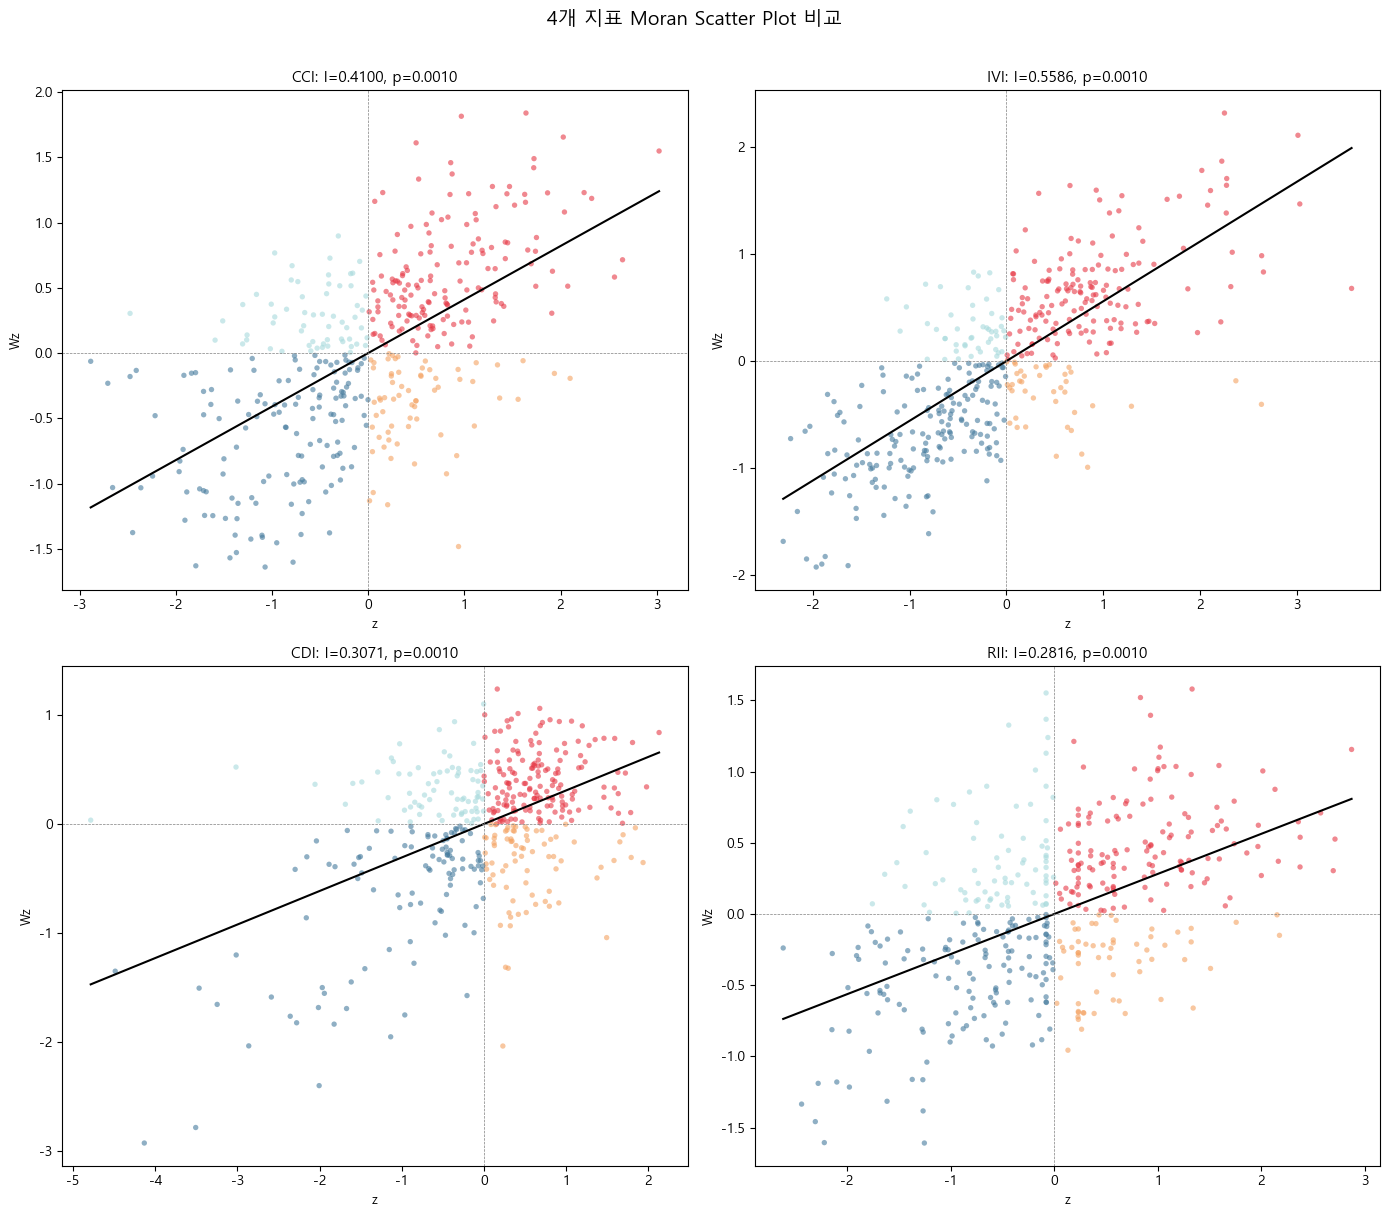

저장: c:\Tsum2026\T_SUM2026\outputs\figures\moran_4panel.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(['CCI', 'IVI', 'CDI', 'RII']):
    mi_col = Moran(gdf[col], w)
    z_col  = (gdf[col].values - gdf[col].mean()) / gdf[col].std()
    wz_col = libpysal.weights.lag_spatial(w, z_col)

    colors = []
    for z, wz in zip(z_col, wz_col):
        if z >= 0 and wz >= 0:   colors.append('#E63946')
        elif z < 0 and wz < 0:   colors.append('#457B9D')
        elif z >= 0 and wz < 0:  colors.append('#F4A261')
        else:                     colors.append('#A8DADC')

    axes[idx].scatter(z_col, wz_col, c=colors, s=15, alpha=0.6, edgecolors='none')
    xfit = np.linspace(z_col.min(), z_col.max(), 100)
    axes[idx].plot(xfit, mi_col.I * xfit, 'k-', linewidth=1.5)
    axes[idx].axhline(0, color='gray', linewidth=0.5, linestyle='--')
    axes[idx].axvline(0, color='gray', linewidth=0.5, linestyle='--')
    axes[idx].set_title(f"{col}: I={mi_col.I:.4f}, p={mi_col.p_sim:.4f}", fontsize=11)
    axes[idx].set_xlabel('z', fontsize=9)
    axes[idx].set_ylabel('Wz', fontsize=9)

plt.suptitle('4개 지표 Moran Scatter Plot 비교', fontsize=14, y=1.01)
plt.tight_layout()
path_4panel = FIG_DIR / 'moran_4panel.png'
plt.savefig(path_4panel, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_4panel}')

---
## 8. HH 핫스팟 동 — triple_high 와의 관계

In [8]:
hh_dongs  = set(gdf[gdf['lisa_cluster'] == 'HH']['행정동명'].values)
tri_dongs = set(gdf[gdf['triple_high_flag'] == 1]['행정동명'].values)

overlap = hh_dongs & tri_dongs
print(f'HH 핫스팟: {len(hh_dongs)}개')
print(f'triple_high: {len(tri_dongs)}개')
print(f'교집합: {len(overlap)}개')
print(f'triple_high 중 HH 포함 비율: {len(overlap)/len(tri_dongs)*100:.1f}%')
print()

hh_df = gdf[gdf['lisa_cluster'] == 'HH'][['자치구명','행정동명','CCI','CCI_rank','triple_high_flag','lisa_I','lisa_p']]
hh_df = hh_df.sort_values('CCI_rank')
print('=== HH 핫스팟 동 전체 목록 ===')
display(hh_df.round(4).reset_index(drop=True))
print()
print('=== 요약 ===')
print(f'  HH이면서 triple_high: {overlap}')
print(f'  HH이지만 triple_high 아님: {hh_dongs - tri_dongs}')
print(f'  triple_high이지만 HH 아님: {tri_dongs - hh_dongs}')

HH 핫스팟: 57개
triple_high: 10개
교집합: 7개
triple_high 중 HH 포함 비율: 70.0%

=== HH 핫스팟 동 전체 목록 ===


,자치구명,행정동명,CCI,CCI_rank,triple_high_flag,lisa_I,lisa_p
0,강북구,번2동,0.6718,1,0,4.6827,0.001
1,은평구,응암3동,0.6462,2,0,1.8899,0.013
2,강북구,수유2동,0.6245,4,1,2.7535,0.003
3,강북구,번3동,0.6192,5,0,2.7601,0.001
4,중랑구,신내2동,0.6054,9,1,2.2052,0.019
5,강북구,번1동,0.6045,10,0,3.3570,0.001
6,은평구,신사2동,0.5935,14,1,2.2892,0.006
7,도봉구,쌍문2동,0.5857,15,0,1.5485,0.009
8,관악구,보라매동,0.5850,17,1,1.3562,0.044
9,강북구,수유3동,0.5840,18,0,2.5682,0.001



=== 요약 ===
  HH이면서 triple_high: {'보라매동', '신사2동', '신내2동', '수유2동', '구산동', '녹번동', '역촌동'}
  HH이지만 triple_high 아님: {'번2동', '장위1동', '휘경2동', '북가좌2동', '답십리2동', '번1동', '장안2동', '신원동', '상봉1동', '월계1동', '수유1동', '제기동', '응암1동', '신사1동', '인수동', '서원동', '망우본동', '갈현2동', '묵2동', '방학3동', '방학2동', '응암2동', '쌍문3동', '미아동', '답십리1동', '도봉1동', '응암3동', '번3동', '난곡동', '창1동', '창2동', '송중동', '창3동', '갈현1동', '방학1동', '한강로동', '쌍문2동', '쌍문1동', '상도3동', '장위3동', '대조동', '삼양동', '우이동', '묵1동', '중앙동', '전농2동', '수유3동', '증산동', '창5동', '신내1동'}
  triple_high이지만 HH 아님: {'방화2동', '도봉2동', '은천동'}


---
## 9. 최종 요약

In [9]:
print('=' * 60)
print('공간 자기상관 분석 (Moran\'s I) 요약')
print('=' * 60)
display(global_df)
print()
print('[LISA 클러스터 분포]')
print(gdf['lisa_cluster'].value_counts().to_string())
print()
print('[HH 핫스팟 ↔ triple_high 교집합]')
print(f'  HH: {len(hh_dongs)}개, triple_high: {len(tri_dongs)}개, 교집합: {len(overlap)}개 ({len(overlap)/len(tri_dongs)*100:.1f}%)')
print()
mi_cci2 = Moran(gdf['CCI'], w)
print(f'결론: CCI Global Moran\'s I = {mi_cci2.I:.4f} (p={mi_cci2.p_sim:.4f})')
if mi_cci2.p_sim < 0.05:
    print('  → CCI는 공간적으로 무작위하지 않으며, 고위험 지역이 특정 구에 군집화되어 있음.')
else:
    print('  → 공간적 무작위성 기각 불가 (p≥0.05)')

공간 자기상관 분석 (Moran's I) 요약


,지표,Moran's I,E[I],z-score,p-value,p-sim,해석
0,CCI,0.4100,-0.0024,14.036,0.0,0.001,유의미한 공간 군집
1,IVI,0.5586,-0.0024,19.093,0.0,0.001,유의미한 공간 군집
2,CDI,0.3071,-0.0024,10.535,0.0,0.001,유의미한 공간 군집
3,RII,0.2816,-0.0024,9.665,0.0,0.001,유의미한 공간 군집



[LISA 클러스터 분포]
lisa_cluster
NS    292
HH     57
LL     55
HL     11
LH      5

[HH 핫스팟 ↔ triple_high 교집합]
  HH: 57개, triple_high: 10개, 교집합: 7개 (70.0%)

결론: CCI Global Moran's I = 0.4100 (p=0.0010)
  → CCI는 공간적으로 무작위하지 않으며, 고위험 지역이 특정 구에 군집화되어 있음.
